In [23]:
# 日本語フォント（Mac向け：Hiragino優先）
import matplotlib as mpl
import matplotlib.font_manager as fm

candidates = ["Hiragino Sans", "Yu Gothic", "Noto Sans CJK JP", "IPAexGothic", "MS Gothic"]
available = {f.name for f in fm.fontManager.ttflist}

for f in candidates:
    if f in available:
        mpl.rcParams["font.family"] = f
        print("font =", f)
        break

mpl.rcParams["axes.unicode_minus"] = False


font = Hiragino Sans


In [24]:
import pandas as pd

path = "../data/raw/reinfolib/shinagawa_mansion_contract_2022Q2-2025Q2.csv"

for enc in ["utf-8-sig", "utf-8", "cp932", "shift_jis"]:
    try:
        df = pd.read_csv(path, encoding=enc)
        print("OK:", enc, df.shape)
        display(df.head())
        break
    except UnicodeDecodeError as e:
        print("NG:", enc, e)


NG: utf-8-sig 'utf-8' codec can't decode byte 0x8e in position 1: invalid start byte
NG: utf-8 'utf-8' codec can't decode byte 0x8e in position 0: invalid start byte
OK: cp932 (3236, 21)


,種類,価格情報区分,市区町村コード,都道府県名,市区町村名,地区名,最寄駅：名称,最寄駅：距離（分）,取引価格（総額）,間取り,...,建築年,建物の構造,用途,今後の利用目的,都市計画,建ぺい率（％）,容積率（％）,取引時期,改装,取引の事情等
0,中古マンション等,成約価格情報,13109,東京都,品川区,荏原,武蔵小山,5.0,9500000,１Ｒ,...,1986年,ＳＲＣ,NaN,NaN,商業,NaN,NaN,2022年第2四半期,NaN,NaN
1,中古マンション等,成約価格情報,13109,東京都,品川区,荏原,武蔵小山,5.0,86000000,３ＬＤＫ,...,2004年,ＲＣ,NaN,NaN,商業,NaN,NaN,2022年第2四半期,NaN,NaN
2,中古マンション等,成約価格情報,13109,東京都,品川区,荏原,武蔵小山,6.0,74000000,２ＬＤＫ,...,2018年,ＲＣ,NaN,NaN,商業,NaN,NaN,2022年第2四半期,NaN,NaN
3,中古マンション等,成約価格情報,13109,東京都,品川区,荏原,武蔵小山,5.0,69000000,２ＬＤＫ,...,2007年,ＲＣ,NaN,NaN,商業,NaN,NaN,2022年第2四半期,NaN,NaN
4,中古マンション等,成約価格情報,13109,東京都,品川区,荏原,西小山,8.0,50000000,１ＬＤＫ,...,1991年,ＲＣ,NaN,NaN,１種住居,NaN,NaN,2022年第2四半期,NaN,NaN


In [25]:
import pandas as pd
from pathlib import Path

csv_path = Path("..") / "data" / "raw" / "reinfolib" / "shinagawa_mansion_contract_2022Q2-2025Q2.csv"
df = pd.read_csv(csv_path, encoding="cp932")

df.shape


(3236, 21)

In [26]:
print(df.columns.tolist())

['種類', '価格情報区分', '市区町村コード', '都道府県名', '市区町村名', '地区名', '最寄駅：名称', '最寄駅：距離（分）', '取引価格（総額）', '間取り', '面積（㎡）', '建築年', '建物の構造', '用途', '今後の利用目的', '都市計画', '建ぺい率（％）', '容積率（％）', '取引時期', '改装', '取引の事情等']


In [27]:
for i, c in enumerate(df.columns):
    print(f"{i:02d}: {c}")

00: 種類
01: 価格情報区分
02: 市区町村コード
03: 都道府県名
04: 市区町村名
05: 地区名
06: 最寄駅：名称
07: 最寄駅：距離（分）
08: 取引価格（総額）
09: 間取り
10: 面積（㎡）
11: 建築年
12: 建物の構造
13: 用途
14: 今後の利用目的
15: 都市計画
16: 建ぺい率（％）
17: 容積率（％）
18: 取引時期
19: 改装
20: 取引の事情等


In [28]:
def pick_col(cands):
    for cand in cands:
        for c in df.columns:
            if cand in str(c):
                return c
    return None

COL = {
    "price": pick_col(["取引価格（総額）", "取引価格", "成約価格", "価格"]),
    "area_m2": pick_col(["面積（㎡）", "面積", "㎡"]),
    "build_year": pick_col(["建築年", "築"]),
    "station": pick_col(["最寄駅：名称", "最寄駅", "駅：名称", "駅名"]),
    "station_min": pick_col(["最寄駅：距離（分）", "距離（分）", "駅距離"]),
    "district": pick_col(["地区名", "町名"]),
    "time": pick_col(["取引時期", "時期"]),
}

COL


{'price': '取引価格（総額）',
 'area_m2': '面積（㎡）',
 'build_year': '建築年',
 'station': '最寄駅：名称',
 'station_min': '最寄駅：距離（分）',
 'district': '地区名',
 'time': '取引時期'}

In [29]:
import pandas as pd
import numpy as np
from pathlib import Path

# さっき確定したCOLをそのまま使う想定
# COL = {...}  # すでに上で作ってあるなら再定義不要

# 使う列（最低限）
use_cols = [
    "都道府県名","市区町村名","地区名",
    "最寄駅：名称","最寄駅：距離（分）",
    "取引価格（総額）","面積（㎡）","建築年",
    "取引時期","間取り","建物の構造","用途"
]
use_cols = [c for c in use_cols if c in df.columns]  # 存在する列だけ

d = df[use_cols].copy()

def to_num(s):
    # "1986年" みたいなのが混ざっても数値にする
    return pd.to_numeric(
        s.astype(str)
         .str.replace(",", "", regex=False)
         .str.replace(r"[^\d\.]", "", regex=True),
        errors="coerce"
    )

d["price"] = to_num(d[COL["price"]])
d["area_m2"] = to_num(d[COL["area_m2"]])
d["build_year"] = to_num(d[COL["build_year"]])
d["station_min"] = to_num(d[COL["station_min"]])

# ㎡単価
d["price_per_m2"] = d["price"] / d["area_m2"]

# 取引時期（例：2022年第2四半期）→ year, q
t = d[COL["time"]].astype(str).str.replace(" ", "")
yq = t.str.extract(r"(?P<year>\d{4})年第(?P<q>\d)四半期")
d["year"] = pd.to_numeric(yq["year"], errors="coerce")
d["q"] = pd.to_numeric(yq["q"], errors="coerce")

# 並び替え用（表示・集計用に使う）
d["quarter_key"] = d["year"].astype("Int64").astype(str) + "Q" + d["q"].astype("Int64").astype(str)

d.head()


,都道府県名,市区町村名,地区名,最寄駅：名称,最寄駅：距離（分）,取引価格（総額）,面積（㎡）,建築年,取引時期,間取り,建物の構造,用途,price,area_m2,build_year,station_min,price_per_m2,year,q,quarter_key
0,東京都,品川区,荏原,武蔵小山,5.0,9500000,15,1986年,2022年第2四半期,１Ｒ,ＳＲＣ,NaN,9500000,15,1986.0,5.0,6.333333e+05,2022,2,2022Q2
1,東京都,品川区,荏原,武蔵小山,5.0,86000000,75,2004年,2022年第2四半期,３ＬＤＫ,ＲＣ,NaN,86000000,75,2004.0,5.0,1.146667e+06,2022,2,2022Q2
2,東京都,品川区,荏原,武蔵小山,6.0,74000000,55,2018年,2022年第2四半期,２ＬＤＫ,ＲＣ,NaN,74000000,55,2018.0,6.0,1.345455e+06,2022,2,2022Q2
3,東京都,品川区,荏原,武蔵小山,5.0,69000000,55,2007年,2022年第2四半期,２ＬＤＫ,ＲＣ,NaN,69000000,55,2007.0,5.0,1.254545e+06,2022,2,2022Q2
4,東京都,品川区,荏原,西小山,8.0,50000000,55,1991年,2022年第2四半期,１ＬＤＫ,ＲＣ,NaN,50000000,55,1991.0,8.0,9.090909e+05,2022,2,2022Q2


In [30]:
display(d.isna().mean().sort_values(ascending=False).head(30))
display(d[["price","area_m2","build_year","station_min","price_per_m2"]].describe())

用途              1.000000
建物の構造           0.052534
最寄駅：距離（分）       0.030902
station_min     0.030902
建築年             0.029666
build_year      0.029666
最寄駅：名称          0.029048
price           0.000000
q               0.000000
year            0.000000
price_per_m2    0.000000
area_m2         0.000000
都道府県名           0.000000
市区町村名           0.000000
間取り             0.000000
取引時期            0.000000
面積（㎡）           0.000000
取引価格（総額）        0.000000
地区名             0.000000
quarter_key     0.000000
dtype: float64

,price,area_m2,build_year,station_min,price_per_m2
count,3.236000e+03,3236.000000,3140.000000,3136.000000,3.236000e+03
mean,7.237092e+07,58.178307,2001.423567,5.433036,1.202923e+06
std,4.559524e+07,20.584099,15.676226,2.682921,5.235838e+05
min,6.300000e+06,15.000000,1964.000000,1.000000,2.500000e+05
25%,4.000000e+07,45.000000,1985.000000,4.000000,8.533333e+05
50%,6.600000e+07,60.000000,2005.000000,5.000000,1.114286e+06
75%,9.100000e+07,70.000000,2015.000000,7.000000,1.433333e+06
max,5.200000e+08,215.000000,2024.000000,16.000000,4.952381e+06


In [31]:
from pathlib import Path

before = len(d)
d2 = d.copy()

# 1) 相場把握に必須の列だけ必須化（用途は全部欠損なので使わない）
req = ["price", "area_m2", "price_per_m2", "quarter_key", "市区町村名", "地区名"]
d2 = d2.dropna(subset=req)

# 2) ありえない値を軽く除外（削りすぎない）
d2 = d2[(d2["price"] > 0) & (d2["area_m2"] > 0)]
d2 = d2[(d2["area_m2"] >= 10) & (d2["area_m2"] <= 250)]  # 念のため少しだけ幅広め

# 3) 外れ値は「分析用に別列でクリップ」（元データは残す）
lo, hi = d2["price_per_m2"].quantile([0.01, 0.99])
d2["price_per_m2_clip"] = d2["price_per_m2"].clip(lo, hi)

after = len(d2)
print(f"rows: {before} -> {after} (removed {before-after})")
print("clip range (price_per_m2):", lo, hi)

d2.head()


rows: 3236 -> 3236 (removed 0)
clip range (price_per_m2): 400000.0 2888888.888888889


,都道府県名,市区町村名,地区名,最寄駅：名称,最寄駅：距離（分）,取引価格（総額）,面積（㎡）,建築年,取引時期,間取り,...,用途,price,area_m2,build_year,station_min,price_per_m2,year,q,quarter_key,price_per_m2_clip
0,東京都,品川区,荏原,武蔵小山,5.0,9500000,15,1986年,2022年第2四半期,１Ｒ,...,NaN,9500000,15,1986.0,5.0,6.333333e+05,2022,2,2022Q2,6.333333e+05
1,東京都,品川区,荏原,武蔵小山,5.0,86000000,75,2004年,2022年第2四半期,３ＬＤＫ,...,NaN,86000000,75,2004.0,5.0,1.146667e+06,2022,2,2022Q2,1.146667e+06
2,東京都,品川区,荏原,武蔵小山,6.0,74000000,55,2018年,2022年第2四半期,２ＬＤＫ,...,NaN,74000000,55,2018.0,6.0,1.345455e+06,2022,2,2022Q2,1.345455e+06
3,東京都,品川区,荏原,武蔵小山,5.0,69000000,55,2007年,2022年第2四半期,２ＬＤＫ,...,NaN,69000000,55,2007.0,5.0,1.254545e+06,2022,2,2022Q2,1.254545e+06
4,東京都,品川区,荏原,西小山,8.0,50000000,55,1991年,2022年第2四半期,１ＬＤＫ,...,NaN,50000000,55,1991.0,8.0,9.090909e+05,2022,2,2022Q2,9.090909e+05


In [32]:
from pathlib import Path

# 出力先フォルダ
out_dir = Path("..") / "outputs" / "tables"
out_dir.mkdir(parents=True, exist_ok=True)

# 読みやすい単位：万円/㎡（円/㎡も残す）
d2["ppm2_man"] = d2["price_per_m2"] / 10000
d2["ppm2_man_clip"] = d2["price_per_m2_clip"] / 10000

# 地区別 相場（中央値＋件数）
summary_district = (
    d2.groupby("地区名")
      .agg(
          n=("ppm2_man", "size"),
          median_man=("ppm2_man", "median"),
          mean_man=("ppm2_man", "mean"),
          median_price=("price", "median"),
          median_area=("area_m2", "median"),
      )
      .reset_index()
      .sort_values("median_man", ascending=False)
)

# 信頼性ルール：n>=30
summary_district_30 = summary_district[summary_district["n"] >= 30].copy()

summary_district.to_csv(out_dir / "price_by_district_all.csv", index=False)
summary_district_30.to_csv(out_dir / "price_by_district_n30.csv", index=False)

print("district unique:", d2["地区名"].nunique())
print("n>=30 rows:", len(summary_district_30))
summary_district_30.head(20)


district unique: 25
n>=30 rows: 20


,地区名,n,median_man,mean_man,median_price,median_area
0,上大崎,192,164.575163,179.857250,87500000.0,55.0
10,小山,132,150.000000,148.593544,86500000.0,60.0
9,大崎,206,146.410256,149.792102,92000000.0,65.0
21,西五反田,387,128.888889,135.651685,70000000.0,55.0
13,戸越,53,123.076923,117.903646,51000000.0,45.0
8,大井,160,122.102564,133.043081,75500000.0,60.0
16,東五反田,247,120.000000,128.116244,68000000.0,60.0
1,中延,75,120.000000,115.396126,65000000.0,55.0
17,東品川,391,116.666667,112.496694,79000000.0,70.0
5,北品川,221,114.117647,127.217806,67000000.0,60.0


In [33]:
from pathlib import Path

out_dir = Path("..") / "outputs" / "tables"
out_dir.mkdir(parents=True, exist_ok=True)

# 全体の四半期推移（中央値・件数）
trend_all = (
    d2.groupby("quarter_key")
      .agg(
          n=("ppm2_man", "size"),
          median_man=("ppm2_man", "median"),
          mean_man=("ppm2_man", "mean"),
      )
      .reset_index()
      .sort_values("quarter_key")
)

# 上位地区（n>=30 かつ ㎡単価中央値が高い上位5）を選ぶ
top5 = summary_district_30.head(5)["地区名"].tolist()

trend_top = (
    d2[d2["地区名"].isin(top5)]
      .groupby(["地区名", "quarter_key"])
      .agg(
          n=("ppm2_man", "size"),
          median_man=("ppm2_man", "median"),
      )
      .reset_index()
      .sort_values(["地区名", "quarter_key"])
)

trend_all.to_csv(out_dir / "trend_all.csv", index=False)
trend_top.to_csv(out_dir / "trend_top5_district.csv", index=False)

print("quarters:", trend_all["quarter_key"].min(), "->", trend_all["quarter_key"].max(), "count:", len(trend_all))
print("top5:", top5)

trend_all.head(10)


quarters: 2022Q2 -> 2025Q2 count: 13
top5: ['上大崎', '小山', '大崎', '西五反田', '戸越']


,quarter_key,n,median_man,mean_man
0,2022Q2,226,100.000000,103.240915
1,2022Q3,190,104.880952,106.916209
2,2022Q4,216,102.500000,107.699724
3,2023Q1,242,110.000000,113.499407
4,2023Q2,213,105.714286,110.487371
5,2023Q3,233,113.333333,114.290329
6,2023Q4,276,120.000000,121.358962
7,2024Q1,241,118.461538,124.843066
8,2024Q2,269,120.000000,123.525132
9,2024Q3,222,108.285714,121.805253


In [34]:
import matplotlib as mpl
import matplotlib.font_manager as fm

# 使えるフォントの中から、日本語っぽいのを優先して選ぶ
candidates = ["Hiragino Sans", "Yu Gothic", "Noto Sans CJK JP", "IPAexGothic", "MS Gothic"]
available = {f.name for f in fm.fontManager.ttflist}

for f in candidates:
    if f in available:
        mpl.rcParams["font.family"] = f
        print("font =", f)
        break

mpl.rcParams["axes.unicode_minus"] = False


font = Hiragino Sans


In [35]:
import matplotlib.pyplot as plt
plt.rcParams["axes.unicode_minus"] = False


In [36]:
import numpy as np
import pandas as pd
import re

def quarter_to_int(x):
    """
    '2022Q2' / '2022-Q2' / '2022  Q2' みたいな表記を想定して並び替え用の数値に変換
    変換できない場合は NaN
    """
    s = str(x)
    m = re.search(r'(\d{4}).*?[Qq](\d)', s)
    if not m:
        return np.nan
    year = int(m.group(1))
    q = int(m.group(2))
    return year * 4 + q

def fmt_val(v):
    return f"{v:.1f}"

def fmt_pct(v):
    return f"{v:.1f}%"


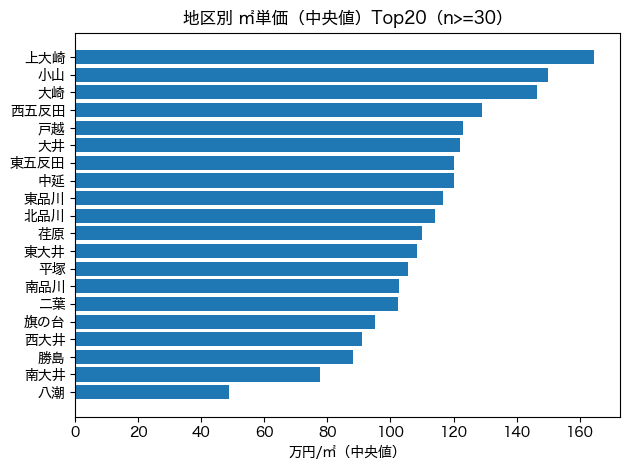

In [37]:
import matplotlib.pyplot as plt
from pathlib import Path

fig_dir = Path("..") / "outputs" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# 1) 地区別ランキング（n>=30, 中央値の高い順 Top20）
top20 = summary_district_30.head(20).sort_values("median_man")
plt.figure()
plt.barh(top20["地区名"], top20["median_man"])
plt.xlabel("万円/㎡（中央値）")
plt.title("地区別 ㎡単価（中央値）Top20（n>=30）")
plt.tight_layout()
plt.savefig(fig_dir / "district_rank_top20.png", dpi=200)
plt.show()

In [38]:
# --- 図①：地区別ランキング Top20（中央値）観察を数値で作る ---
top20_desc = top20.sort_values("median_man", ascending=False).reset_index(drop=True)

top3 = top20_desc.loc[:2, ["地区名", "median_man"]]
max_row = top20_desc.iloc[0][["地区名", "median_man"]]
min_row = top20_desc.iloc[-1][["地区名", "median_man"]]

max_v = float(max_row["median_man"])
min_v = float(min_row["median_man"])
range_v = max_v - min_v
pct_gap = (max_v / min_v - 1) * 100 if min_v != 0 else np.nan

med = float(top20_desc["median_man"].median())
q25 = float(top20_desc["median_man"].quantile(0.25))
q75 = float(top20_desc["median_man"].quantile(0.75))
iqr = q75 - q25

# “段差（落ち方）”が一番大きい箇所（順位 r → r+1）
diff_to_next = top20_desc["median_man"] - top20_desc["median_man"].shift(-1)
drop_idx = int(diff_to_next.iloc[:-1].idxmax())
drop_val = float(diff_to_next.iloc[drop_idx])
drop_r = drop_idx + 1  # 1始まり順位

# Markdown貼り付け用（観察だけ）
lines = []
lines.append("### 観察（図から事実として言えること：自動算出）")
lines.append(f"- 上位3地区："
             f"{top3.iloc[0]['地区名']}（{fmt_val(top3.iloc[0]['median_man'])}） / "
             f"{top3.iloc[1]['地区名']}（{fmt_val(top3.iloc[1]['median_man'])}） / "
             f"{top3.iloc[2]['地区名']}（{fmt_val(top3.iloc[2]['median_man'])}） 〔単位：万円/㎡〕")
lines.append(f"- Top20内 最大：{max_row['地区名']}（{fmt_val(max_v)}） / 最小：{min_row['地区名']}（{fmt_val(min_v)}） → レンジ：{fmt_val(range_v)} 万円/㎡（相対差：{fmt_pct(pct_gap)}）")
lines.append(f"- 分布：中央値 {fmt_val(med)}、IQR（Q75-Q25） {fmt_val(iqr)}（Q25={fmt_val(q25)}, Q75={fmt_val(q75)}）")
lines.append(f"- 段差が最大：順位{drop_r}→{drop_r+1}で {fmt_val(drop_val)} 万円/㎡ 下がる")

print("\n".join(lines))


### 観察（図から事実として言えること：自動算出）
- 上位3地区：上大崎（164.6） / 小山（150.0） / 大崎（146.4） 〔単位：万円/㎡〕
- Top20内 最大：上大崎（164.6） / 最小：八潮（48.8） → レンジ：115.8 万円/㎡（相対差：237.6%）
- 分布：中央値 112.1、IQR（Q75-Q25） 21.8（Q25=100.5, Q75=122.3）
- 段差が最大：順位19→20で 28.9 万円/㎡ 下がる


## 読み方

* **横軸：㎡単価（指標：中央値）／縦軸：地区（上位20）**
* 「地区間の価格差」と「上位地区の集中度」を見る図

## 観察（図から事実として言えること）

* 上位3地区：**上大崎（164.6） / 小山（150.0） / 大崎（146.4）**〔単位：万円/㎡〕
* Top20内 最大：**上大崎（164.6）** / 最小：**八潮（48.8）** → **レンジ：115.8 万円/㎡（相対差：237.6%）**
* 分布：中央値 **112.1**、IQR（Q75−Q25）**21.8**（Q25=**100.5**, Q75=**122.3**）
* 段差が最大：**順位19→20で 28.9 万円/㎡ 下がる**

## 示唆（業務での使い道）

* **エリア別戦略**：価格差が大きいため、**上位エリア優先**で「販売・仕入れ・広告配分」を設計できる
* **顧客提案**：同条件で比較する際に「予算帯ごとの候補地区（上位/中位/下位）」を提示しやすい
* **異常検知**：上位が突出している場合、築年・駅距離・面積などの偏りの可能性 → 次の切り分けに繋げられる

## 次アクション（1つだけ）

* `district × 築年帯` で再集計し、上位地区が「立地」なのか「築浅比率」なのかを切り分ける

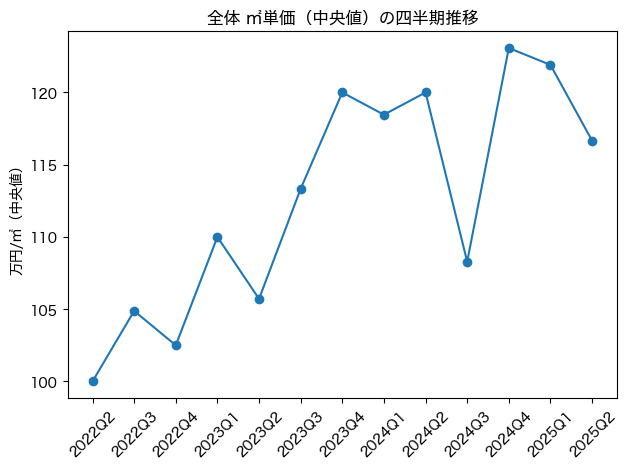

In [47]:
# 2) 全体の四半期推移（中央値）
plt.figure()
plt.plot(trend_all["quarter_key"], trend_all["median_man"], marker="o")
plt.xticks(rotation=45)
plt.ylabel("万円/㎡（中央値）")
plt.title("全体 ㎡単価（中央値）の四半期推移")
plt.tight_layout()
plt.savefig(fig_dir / "trend_all_median.png", dpi=200)
plt.show()

In [51]:
# --- 図②：全体 四半期推移（中央値）観察を数値で作る ---
t = trend_all.copy()
t["_q"] = t["quarter_key"].apply(quarter_to_int)
t = t.dropna(subset=["_q"]).sort_values("_q").reset_index(drop=True)

first_q, first_v = t.loc[0, "quarter_key"], float(t.loc[0, "median_man"])
last_q, last_v = t.loc[len(t)-1, "quarter_key"], float(t.loc[len(t)-1, "median_man"])
chg = last_v - first_v
chg_pct = (last_v / first_v - 1) * 100 if first_v != 0 else np.nan

peak_i = int(t["median_man"].idxmax())
low_i  = int(t["median_man"].idxmin())
peak_q, peak_v = t.loc[peak_i, "quarter_key"], float(t.loc[peak_i, "median_man"])
low_q,  low_v  = t.loc[low_i,  "quarter_key"], float(t.loc[low_i,  "median_man"])

# 前期差（QoQ）を計算
t["qoq"] = t["median_man"].diff()
# 最大上昇 / 最大下落（前期差）
up_i = int(t["qoq"].idxmax())
dn_i = int(t["qoq"].idxmin())
up_q, up_d = t.loc[up_i, "quarter_key"], float(t.loc[up_i, "qoq"])
dn_q, dn_d = t.loc[dn_i, "quarter_key"], float(t.loc[dn_i, "qoq"])

# ばらつき（変動の大きさ）
std = float(t["median_man"].std())
rng = float(t["median_man"].max() - t["median_man"].min())

lines = []
lines.append("### 観察（図から事実として言えること：自動算出）")
lines.append(f"- 期間：{first_q} → {last_q}")
lines.append(f"- 期間変化：{fmt_val(first_v)} → {fmt_val(last_v)}（差分 {fmt_val(chg)} 万円/㎡、変化率 {fmt_pct(chg_pct)}）")
lines.append(f"- 最高値：{peak_q}（{fmt_val(peak_v)}） / 最低値：{low_q}（{fmt_val(low_v)}） → レンジ {fmt_val(rng)}")
lines.append(f"- 最大上昇（前期差 QoQ）：{up_q} で +{fmt_val(up_d)} / 最大下落（前期差 QoQ）：{dn_q} で {fmt_val(dn_d)} 〔単位：万円/㎡〕")
lines.append(f"- 変動の大きさ（標準偏差）：{fmt_val(std)}")

print("\n".join(lines))


### 観察（図から事実として言えること：自動算出）
- 期間：2022Q2 → 2025Q2
- 期間変化：100.0 → 116.7（差分 16.7 万円/㎡、変化率 16.7%）
- 最高値：2024Q4（123.1） / 最低値：2022Q2（100.0） → レンジ 23.1
- 最大上昇（前期差 QoQ）：2024Q4 で +14.8 / 最大下落（前期差 QoQ）：2024Q3 で -11.7 〔単位：万円/㎡〕
- 変動の大きさ（標準偏差）：7.9


図２

## 読み方

* 横軸：四半期（quarter）／縦軸：㎡単価（**中央値**、単位：万円/㎡）
* 市場全体の「上昇・下落・横ばい」と、変化のタイミングを確認する図

## 観察（図から事実として言えること）

* 期間：**2022Q2 → 2025Q2**
* 期間変化：**100.0 → 116.7**（差分 **+16.7 万円/㎡**、変化率 **+16.7%**）
* 最高値：**2024Q4（123.1）** ／ 最低値：**2022Q2（100.0）** → レンジ **23.1 万円/㎡**
* 最大上昇（前期差 QoQ）：**2024Q4 で +14.8** ／ 最大下落（前期差 QoQ）：**2024Q3 で -11.7**（単位：万円/㎡）
* 変動の大きさ（標準偏差）：**7.9**
* 変化の特徴：**2024Q3で下落（-11.7）の後、2024Q4で反発（+14.8）**が見られる

## 示唆（業務での使い道）

* **相場の基準線**：期間で**+16.7%**上昇しているため、個別物件の価格が「市場全体に対して高い／安い」を説明する根拠になる
* **施策タイミング**：変化が大きい四半期（例：2024Q3→Q4）を起点に、広告強化・仕入れ判断の検討材料にできる
* **モニタリング指標**：四半期ごとの中央値をKPIとして定点観測し、市況変化を早期に把握できる

## 次アクション（1つだけ）

* QoQ（前期差）を系列として表・グラフ化し、**変化が大きい四半期**を一覧で特定する（例：上位3つを抽出）


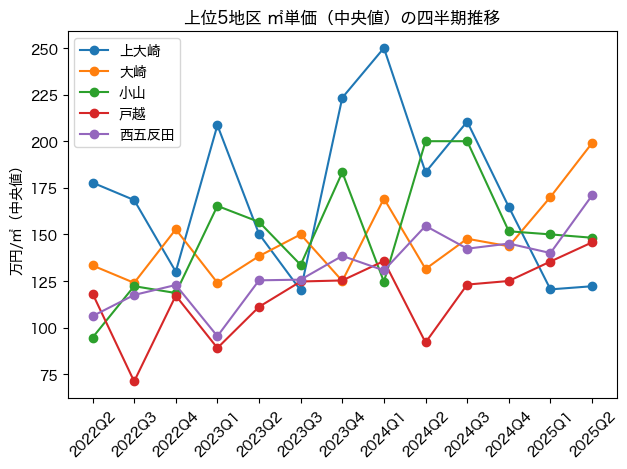

In [52]:
# 3) 上位5地区の四半期推移（中央値）
tmp = trend_top.pivot(index="quarter_key", columns="地区名", values="median_man").sort_index()
plt.figure()
for col in tmp.columns:
    plt.plot(tmp.index, tmp[col], marker="o", label=col)
plt.xticks(rotation=45)
plt.ylabel("万円/㎡（中央値）")
plt.title("上位5地区 ㎡単価（中央値）の四半期推移")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "trend_top5_median.png", dpi=200)
plt.show()

In [ ]:
# --- 図③：上位地区（top5）の推移比較 観察を数値で作る ---
# tmp: index=quarter_key, columns=地区名, values=median_man を想定
tmp2 = tmp.copy()
tmp2["_q"] = pd.Index(tmp2.index).map(quarter_to_int)
tmp2 = tmp2.dropna(subset=["_q"]).sort_values("_q").drop(columns="_q")

# 各地区の「初期→最新」の変化
first = tmp2.iloc[0]
last  = tmp2.iloc[-1]
delta = last - first
pct   = (last / first - 1) * 100

# “伸びが強い”＝差分deltaが最大
best_area = delta.idxmax()
best_delta = float(delta.max())
best_pct = float(pct[best_area])

# “安定”＝標準偏差が最小
std_by_area = tmp2.std(axis=0)
stable_area = std_by_area.idxmin()
stable_std = float(std_by_area.min())

# 乖離（地区間の差）の変化：各四半期の max-min
spread = tmp2.max(axis=1) - tmp2.min(axis=1)
spread_first = float(spread.iloc[0])
spread_last  = float(spread.iloc[-1])
spread_chg   = spread_last - spread_first

# 最新時点で一番高い地区
top_last_area = last.idxmax()
top_last_val = float(last.max())

lines = []
lines.append("### 観察（図から事実として言えること：自動算出）")
lines.append(f"- 最新四半期（{tmp2.index[-1]}）で最高：{top_last_area}（{fmt_val(top_last_val)} 万円/㎡）")
lines.append(f"- 伸びが最大（初期→最新の差分）：{best_area}（+{fmt_val(best_delta)} 万円/㎡、変化率 {fmt_pct(best_pct)}）")
lines.append(f"- 最も安定（標準偏差が最小）：{stable_area}（標準偏差 {fmt_val(stable_std)}）")
lines.append(f"- 地区間の乖離（max-min）：初期 {fmt_val(spread_first)} → 最新 {fmt_val(spread_last)}（差分 {fmt_val(spread_chg)}）")

print("\n".join(lines))


### 観察（図から事実として言えること：自動算出）
- 最新四半期（2025Q2）で最高：大崎（199.0 万円/㎡）
- 伸びが最大（初期→最新の差分）：大崎（+65.7 万円/㎡、変化率 49.3%）
- 最も安定（標準偏差が最小）：西五反田（標準偏差 20.0）
- 地区間の乖離（max-min）：初期 83.2 → 最新 76.8（差分 -6.3）


図３

## 読み方

* 横軸：四半期（quarter）／縦軸：㎡単価（**中央値**、単位：万円/㎡）
* 上位地区（Top5）の「伸び方の違い」「安定性」「地区間の乖離（max-min）」を比較する図

## 観察（図から事実として言えること）

* 最新四半期（**2025Q2**）で最高：**大崎（199.0 万円/㎡）**
* 伸びが最大（初期→最新の差分）：**大崎（+65.7 万円/㎡、変化率 49.3%）**
* 最も安定（標準偏差が最小）：**西五反田（標準偏差 20.0）**
* 地区間の乖離（max-min）：初期 **83.2** → 最新 **76.8**（差分 **-6.3**）

## 示唆（業務での使い道）

* **注力エリア選定**：伸びが大きい **大崎** を注力エリア候補として、営業・広告・仕入れの優先度を上げる判断材料になる
* **提案の説得力**：上位地区でも伸び方・安定性が異なるため、「なぜこのエリアを推すのか」をデータで説明できる
* **比較提案**：乖離（max-min）が縮小しているため、上位地区間の差が相対的に小さくなってきている可能性があり、代替候補の提示（上位内での比較）に使える

## 次アクション（1つだけ）

* 取引件数（volume）の推移も併記し、価格上昇が「需要増」なのか「成約少でブレ」なのかを切り分ける

